# Processing solar corona images from total eclipse

This notebook shows full solar eclipse image processing pipeline. Current version works with Nicole Sharp's [data](https://www.cloudynights.com/forums/topic/919153-have-my-eclipse-raws/#findComment-13397853).

First few cells with auxiliar uninteresting stuff

In [1]:
import sys
from pathlib import Path


def v0_package_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "eclipse_v0").is_dir():
        return cwd
    if (cwd / "v0" / "eclipse_v0").is_dir():
        return cwd / "v0"
    raise RuntimeError(
        "Could not find eclipse_v0: set cwd to the `v0` directory or the repo root."
    )


V0_ROOT = v0_package_root()
if str(V0_ROOT) not in sys.path:
    sys.path.insert(0, str(V0_ROOT))

In [2]:
# GPU selection — same defaults as legacy `eda00.py`. Override in the shell, e.g.
#   CUDA_VISIBLE_DEVICES=0 jupyter lab
from eclipse_v0.device import configure_cuda_visible_devices, require_cuda

configure_cuda_visible_devices()
require_cuda()

In [1]:
import os
from pathlib import Path

DATA_ROOT = Path(os.environ.get("EDA00_DATA_ROOT", "/home/slavik/e202602_eclipse/data"))
WORKDIR = Path(os.environ.get("ECLIPSE_V0_WORKDIR", "/home/slavik/tmp/eclipse_v0_run"))
WORKDIR.mkdir(parents=True, exist_ok=True)

PK_EDA00 = WORKDIR / "v0-eda00.pkl"
PK_EDA02 = WORKDIR / "v0-eda02.pkl"
PK_EDA03 = WORKDIR / "v0-eda03.pkl"

## Stage 0 — ingest, moon, intra-exposure registration

### 0a — Scan disk → `ImageInfo` list

First scan of images: 100%|██████████| 84/84 [00:15<00:00,  5.29it/s]


We have 84 images, first one is /home/slavik/e202602_eclipse/data/img_0150_53657076894_o.jpg

Example images - one per each exposure time


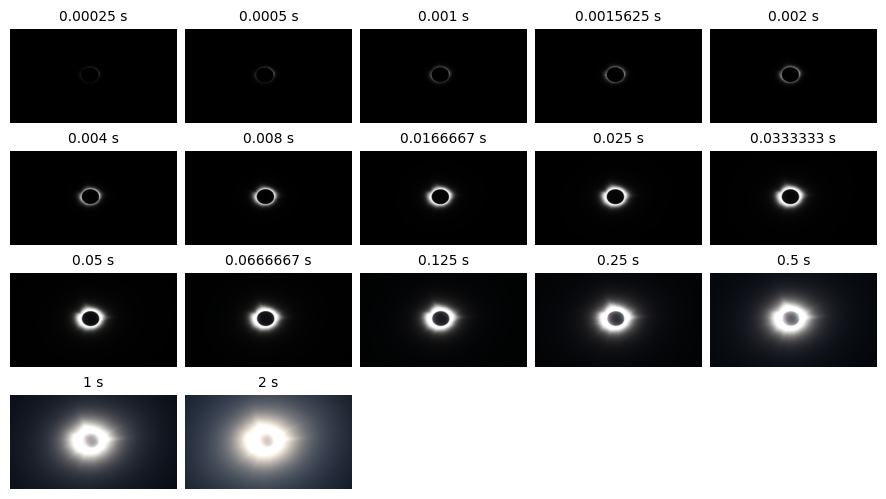

In [4]:
import pipeline
from eclipse_v0 import stage0 as s0

# find all images, obtain basic informations about them (size, avg brighness, etc)
image_infos = s0.get_image_infos(DATA_ROOT)
print(f'We have {len(image_infos)} images, first one is {image_infos[0].path}')
# group images by exposure time
exposure_groups = s0.stage0_group_by_exposure(image_infos)
print('\nExample images - one per each exposure time')
pipeline.plot_exposure_group_thumbnails(exposure_groups)

### 0b — Moon detection (loop over every frame)

Our Moon detection is based on assumption that Moon is dark circle surrounded with brighter cloud, where the cloud has sharp circular inner border. One difficulty which makes it nontrivial are protuberances - small blobs much brighter than rest of the corona. They can confuse many naive approaches. And the assumption "sharp circular inner border" is not valid for long exposures where light polute area of Moon disc. Our algorithm fails there, we just detect this failure, erase affected Moon info and replace it with interpolation from successful frames.

Our algorithm is overcomplicated, I don't claim hat it has to be so complex. Anyway, here it is: `stage0_detect_moons()` first downscale image to manageable size, then examine all possible pairs of concentric circles where bigger circle radius is 2px bigger than smaller one, for each circle it compute sum of pixel values around circle boundary, and it pick the circle pair with biggest difference of this quantity between bigger and smaller circle. This gives first approximate of Moon center. With this in hand we move to full resolution, where we split image to 360 radial 1° pie segments from this approximated center. In each segment we identify point with biggest radial gradient. So we have 360 candidate border points. From these points we form 1024 random triplets and for each triplet we find circumcenter. So we have cluster 1024 center candidates. Using AHC library we find dense core of this cluster defined 256 most tightly packed points. We average them obtaining final Moon center. And because for each center candidate we have know the correspnding Moon radius (as we know the triplet of border points which gave us the center candidate), we can average these radii for our 256 best center candidates, obtaining Moon radius estimation.

Looking at the results: shorter exposure yields quite consistent Moon estimation (small `np.std(radii)` within the group). An Moon radious gently decrease with growing exposure time. Of course the Monn doesn't shrink physically, but for longer exposures the light starts to polute moon disk area due to camera imperefections. This phenomenon explode for really long exposures where Moon parameters are entirely off.

In [5]:
# in each image independently, determine moon position and radius
s0.stage0_detect_moons(image_infos)
print(f'Exposure groups initial state')
s0.stage0_print_exposure_groups_stats(exposure_groups)
# Some moon estimations are just wrong. Identify them and erase them
print(f'Pruning failed Moon estimations')
s0.stage0_prune_moon_info_for_radius_outliers(exposure_groups)

Finding moon: 100%|██████████| 84/84 [01:02<00:00,  1.35it/s]

Exposure groups initial state
exposure_time=0.00025 len(group)=6 np.mean(radii)=316.06 np.std(radii)=0.05
exposure_time=0.00050 len(group)=7 np.mean(radii)=316.04 np.std(radii)=0.06
exposure_time=0.00100 len(group)=4 np.mean(radii)=315.98 np.std(radii)=0.02
exposure_time=0.00156 len(group)=4 np.mean(radii)=315.82 np.std(radii)=0.08
exposure_time=0.00200 len(group)=4 np.mean(radii)=315.84 np.std(radii)=0.07
exposure_time=0.00400 len(group)=4 np.mean(radii)=315.60 np.std(radii)=0.05
exposure_time=0.00800 len(group)=4 np.mean(radii)=315.25 np.std(radii)=0.15
exposure_time=0.01667 len(group)=5 np.mean(radii)=314.38 np.std(radii)=0.24
exposure_time=0.02500 len(group)=5 np.mean(radii)=314.01 np.std(radii)=0.12
exposure_time=0.03333 len(group)=5 np.mean(radii)=313.65 np.std(radii)=0.38
exposure_time=0.05000 len(group)=4 np.mean(radii)=313.27 np.std(radii)=0.16
exposure_time=0.06667 len(group)=5 np.mean(radii)=313.29 np.std(radii)=0.07
exposure_time=0.12500 len(group)=5 np.mean(radii)=312.52 n

### 0c — Interpolate missing positions; set position uncertainty

In [6]:
interp = s0.stage0_interpolate_missing_moons(image_infos, exposure_groups)
s0.stage0_set_moon_position_std(image_infos, exposure_groups, interp)

moon_position_uncertainty_px=2.05


### 0d — Intra-exposure registration: all ordered pairs per group (slow)

Slowest part of pipeline, registration (alignment) of images within each exposure group. It's slow because we are computing alignment of each image pair within group, distinguishing even order (A to B computed seprately from B to A). And the registration is nontrivial because we need to align corona (blurry), not the Moon border which is nice and sharp, but is significantly moving wrt our real target - the corona.

Our regisrtation algorithm does gridsearch of transformations of image B which would lead to good alignment with image A. For scoring 'goodness' of alignment we mask out Moon from both images, filter out lowfeq tangential components, clip some extremely high intensities (protuberances), and  use mean absolute error. Cliping of protuberance intensities is because protuberances evolve quickly. We clip the intensities because we still want to use protuberances as landmarks, but we dont want them to dominate the alignment score. 

Regarding output: for each exposure group you see progress of its processing and once it's done, there is output like
```
Check 1: ij mean=0.1423 max=0.5546  rot mean=0.0104 max=0.0781
Check 2: ij mean=0.2621 max=1.1061  rot mean=0.0339 max=0.0781
```
Its doing two checks. Check 1 takes all registration pairs of images `A`, `B` and checks how much is found alignment transformation `A->B` consistent with `B->A`. It outputs stats of found discrepancy in pixels, first for translation (in our example values `mean=0.1423 max=0.5546`) and then for rotation component of found transform (in our example `rot mean=0.0104 max=0.0781`). Check 2 does similar discrepance check between composed transform `A->B, B->C` and direct `A->C` for all triplets in exposure group.

In [7]:
reg = s0.stage0_register_intra_exposure_pairs(exposure_groups)
s0.stage0_save_pickle(exposure_groups, reg, PK_EDA00)

Doing check for exposure time 0.00025


Registration pairs: 100%|██████████| 30/30 [10:20<00:00, 20.67s/it]


  Check 1: ij mean=0.1423 max=0.5546  rot mean=0.0104 max=0.0781
  Check 2: ij mean=0.2621 max=1.1061  rot mean=0.0339 max=0.0781
Doing check for exposure time 0.0005


Registration pairs: 100%|██████████| 42/42 [13:30<00:00, 19.30s/it]


  Check 1: ij mean=0.1820 max=0.7331  rot mean=0.0074 max=0.0781
  Check 2: ij mean=0.1969 max=0.8471  rot mean=0.0164 max=0.0781
Doing check for exposure time 0.001


...

Registration pairs: 100%|██████████| 72/72 [29:10<00:00, 24.31s/it]


  Check 1: ij mean=0.2707 max=2.2652  rot mean=0.0022 max=0.0781
  Check 2: ij mean=0.4248 max=3.3085  rot mean=0.0126 max=0.0781
Doing check for exposure time 2.0


Registration pairs: 100%|██████████| 12/12 [04:41<00:00, 23.46s/it]

  Check 1: ij mean=0.1332 max=0.8002  rot mean=0.0000 max=0.0000
  Check 2: ij mean=0.3832 max=0.4335  rot mean=0.0000 max=0.0000
Saved /home/slavik/tmp/eclipse_v0_run/v0-eda00.pkl (exposure_groups, reg)


PosixPath('/home/slavik/tmp/eclipse_v0_run/v0-eda00.pkl')

## Stage 1 — prune stacks, global pose fit per exposure

1. **Load** stage-0 pickle.
2. **Prune:** brightness outliers (large groups), then triplet-inconsistent frames.
3. **Per exposure (loop):** treat pairwise `reg` as observations; **Adam** first on angles then shifts so implied transforms match all edges (two 50k phases in `run_group`).
4. **Debug outputs:** random crop, weighted-mean crop, GIF of aligned frames per exposure.
5. **Pickle** pruned groups, plain `reg`, and `opt_results` (`abs_xy`, `abs_angle_t`).

### 1a — Pruning of images within exposure groups

It has two steps. First we throw away images with average brightness too different from rest of the group. Then we remove images, which contribute most to inconsistent registrations (with too big difference between composed `A->B, B->C` and direct `A->C`).


In [2]:
import torch
from eclipse_v0 import stage1 as s1

exposure_groups, reg = s1.stage1_load(PK_EDA00)
s1.stage1_prune_groups(exposure_groups, reg)

prune_brightness_outliers: exp=1.00000 removed image (idx 8) img_0227_53655846522_o.jpg brightness=0.495798 group_std 0.075797 -> 0.020027
prune_failed_registrations: exp=0.00025 removed image (idx 1) img_0145_53657190740_o.jpg


### 2b — Optimization loop (one solve per exposure time)

In [ ]:
device = torch.device("cuda")
opt_results = s1.stage1_optimize_poses_and_debug(
    exposure_groups, reg, device, debug_img_dir=WORKDIR
)

In [ ]:
s1.stage1_save_pickle(PK_EDA02, exposure_groups, reg, opt_results)

## Stage 2 — full-res stack mean per exposure, then cross-exposure chain

1. **Load** stage-2 pickle.
2. **Moon table:** median `(i,j,r)` per exposure (masks for gamma / registration).
3. **Loop exposures (time order):** rebuild **full-size weighted average** (same masking/warp as stage 1).
4. **Loop consecutive pairs `(t0,t1)`:** estimate **gamma** (MAE outside moon); **register** longer stack to shorter using masked Fourier metric (implementation in library); **refine gamma** after alignment; save comparison GIF.
5. **Pickle** `cross_reg` and `gamma_by_pair`.

In [ ]:
from eclipse_v0 import stage2 as s2

exposure_groups, _reg, opt_results = s2.stage2_load(PK_EDA02)
moon_by_exp, exposure_times_sorted = s2.stage2_moon_median_table(exposure_groups)

### 3b — Full-resolution averaged image per exposure

In [ ]:
avg_images = s2.stage2_fullsize_averages(
    exposure_groups, exposure_times_sorted, opt_results, device
)

### 3c — Consecutive exposure pairs: gamma + cross registration

In [ ]:
pairs_results = s2.stage2_cross_exposure_consecutive_pairs(
    exposure_times_sorted, avg_images, moon_by_exp, device, pair_gif_dir=WORKDIR
)
s2.stage2_save_pickle(PK_EDA03, pairs_results)

## Stage 3 — reference merge, radial tone, **patch FFT sharpen**, RGB

The next code cell uses a **`Stage3Context`** and explicit **`stage3_*` steps** (same math as `run_stage3(WORKDIR)`).

**A →** `stage3_load_inputs` — reload `v0-eda02.pkl` / `v0-eda03.pkl`; drop first two exposure times; set reference and `moon_ref`.

**B →** `stage3_build_per_exposure_averages` then `stage3_warp_merge_to_composite` — GPU stack means; chain `cross_reg` + gamma scaling; weighted merge to reference grid.

**C →** `stage3_crop_and_save_composite` — mutual-valid crop; `v0-eda05_composite.npy` + preview.

**D →** `stage3_radial_normalize_display` — moon refine, polar tone + **p3** stretch → `ctx.display`.

**E →** `stage3_fft_unsharp_and_save` — patch FFT unsharp (σ ∈ {2,4,8}, weights `STAGE3_UNSHARP_WEIGHTS`).

**F →** `stage3_rgb_vignette_and_radial_pickle` — RGB + vignette; `v0-eda05_radial.pkl`.

**A. Reload** stage 1+2 pickles; drop first two exposure times (same as `eda05`); pick **reference** = shortest remaining; recompute per-exposure averages in that time list.

**B. Warp + weighted merge** every exposure into the reference grid (chain `cross_reg`, gamma-based intensity scaling, radial weights).

**C. Crop** to mutual valid footprint; save float composite + preview PNG.

**D. Radial pipeline (GPU):** warp to polar, angular statistics / extrapolation, piecewise tone map, **p3** percentile curve, normalize — details in library; outcome is a display-range grayscale `display`.

**E. FFT sharpen (this is the patch loop you asked to surface):**
- Build **difference** `display - blurred(display)` with plain Gaussian and a polar-band blur (library).
- **Tile** the image with square patches (`STAGE3_PATCH_SIDE` × `STAGE3_PATCH_SIDE`, stride `STAGE3_PATCH_STRIDE`).
- **For each patch origin** `(r0, c0)` and each blur scale **σ ∈ {2,4,8}**:
  - `FFT2` → `fftshift` → **spectral processing** (amplitude shaping in polar layout + percentile gates; moon-aware masking — **hidden in library**) → `ifftshift` → `IFFT2` → real part.
  - **Overlap-add** with a smooth circular window.
- **Combine** the three smoothed residual maps with weights `STAGE3_UNSHARP_WEIGHTS`, add back to `display`, clip, zero moon disk.

**F. RGB + vignette** on sharpened gray; save PNG and `v0-eda05_radial.pkl` sidecar.

In [ ]:
import pickle
from eclipse_v0.stage3 import (
    STAGE3_FFT_INWARD_MEDIAN_SPAN,
    STAGE3_PATCH_SIDE,
    STAGE3_PATCH_STRIDE,
    STAGE3_UNSHARP_GAUSSIAN_SIGMAS,
    STAGE3_UNSHARP_WEIGHTS,
    stage3_count_fft_patch_placements,
)

with open(PK_EDA02, "rb") as fd:
    _eg = pickle.load(fd)
_sample = next(iter(_eg.values()))[0]
H0, W0 = _sample.height, _sample.width
nr, nc, n_tot = stage3_count_fft_patch_placements(H0, W0)
print(
    "FFT sharpen patch scan (on radial output, size ≈ crop — often smaller than full frame):\n"
    f"  full-frame geometry if we ran on {H0}x{W0}: grid {nr}x{nc} origins = {n_tot} patches per σ\n"
    f"  patch={STAGE3_PATCH_SIDE}px stride={STAGE3_PATCH_STRIDE}\n"
    f"  Gaussian σ for residual blur: {STAGE3_UNSHARP_GAUSSIAN_SIGMAS}\n"
    f"  combine weights: {STAGE3_UNSHARP_WEIGHTS}\n"
    f"  polar median span on |F| (library): {STAGE3_FFT_INWARD_MEDIAN_SPAN}"
)

In [ ]:
from eclipse_v0.stage3 import (
    Stage3Context,
    stage3_build_per_exposure_averages,
    stage3_crop_and_save_composite,
    stage3_fft_unsharp_and_save,
    stage3_load_inputs,
    stage3_radial_normalize_display,
    stage3_rgb_vignette_and_radial_pickle,
    stage3_warp_merge_to_composite,
)

ctx = Stage3Context(workdir=WORKDIR)
stage3_load_inputs(ctx)
stage3_build_per_exposure_averages(ctx)
stage3_warp_merge_to_composite(ctx)
stage3_crop_and_save_composite(ctx)
stage3_radial_normalize_display(ctx)
stage3_fft_unsharp_and_save(ctx)
stage3_rgb_vignette_and_radial_pickle(ctx)

### After run: patch count on actual composite crop

In [ ]:
import numpy as np
from eclipse_v0.stage3 import stage3_count_fft_patch_placements

comp = np.load(WORKDIR / "v0-eda05_composite.npy")
h, w = comp.shape
nr, nc, nt = stage3_count_fft_patch_placements(h, w)
print(f"Composite crop {h}x{w}: FFT sharpen uses {nr}x{nc} = {nt} patch starts per σ")

## Quick look (optional)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

composite = np.load(WORKDIR / "v0-eda05_composite.npy")
rgb = np.asarray(Image.open(WORKDIR / "v0-eda05_rgb_rescaled.png")) / 255.0
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(composite, cmap="gray")
axes[0].set_title("composite (float crop)")
axes[1].imshow(rgb)
axes[1].set_title("RGB export")
plt.tight_layout()
plt.show()

---

**One-shot alternative** (same math, fewer visible steps): `s0.run_stage0(DATA_ROOT, PK_EDA00)`, `s1.run_stage1(...)`, `s2.run_stage2(...)`, and either `run_stage3(WORKDIR)` or the stepped `Stage3Context` + `stage3_*` calls above.